# Problem Solution Pipeline 

In [1]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import logging
import sys
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, mean_absolute_error, r2_score)
from sklearn.utils.class_weight import compute_sample_weight

## Logging Setup
Configures logging to write to both a file (`pipeline.log`) and the console simultaneously.

In [2]:
# Create a named logger for this pipeline — using a specific name scopes it to this module
logger = logging.getLogger("ierad_pipeline")
logger.setLevel(logging.DEBUG)  # capture all levels: DEBUG, INFO, WARNING, ERROR, CRITICAL

# FileHandler writes every log entry to pipeline.log on disk
file_handler = logging.FileHandler("pipeline.log", mode="w")
file_handler.setLevel(logging.DEBUG)

# StreamHandler mirrors logs to the notebook console output
console_handler = logging.StreamHandler(sys.stdout)
console_handler.setLevel(logging.INFO)  # only INFO and above shown in console

# Formatter controls the structure of each log line
formatter = logging.Formatter(
    fmt="%(asctime)s | %(levelname)-8s | %(message)s",
    datefmt="%Y-%m-%d %H:%M:%S"
)
file_handler.setFormatter(formatter)
console_handler.setFormatter(formatter)

# Attach both handlers so every logger.x() call goes to both destinations
logger.addHandler(file_handler)
logger.addHandler(console_handler)

logger.info("Logging initialised — writing to pipeline.log")

2026-03-30 21:22:35 | INFO     | Logging initialised — writing to pipeline.log


## 1. Data Preparation 
 DuckDB runs in-process — no server needed. We register each parquet file as a view so it can be queried with SQL directly without loading into memory.

In [3]:
# Parquet file paths relative to the scripts/ directory
PARQUET_PATHS = {
    "incident":      "../parquet-data/incident.parquet",
    "environmental": "../parquet-data/environmental_conditions.parquet",
    "resource":      "../parquet-data/resource.parquet",
    "dispatch":      "../parquet-data/dispatch.parquet",
}

try:
    # Open an in-memory DuckDB connection — no external database server required
    con = duckdb.connect()

    # Register each parquet file as a SQL view
    # Views are lazy — data is only read when a query runs against them
    for view_name, path in PARQUET_PATHS.items():
        con.execute(f"CREATE VIEW {view_name} AS SELECT * FROM read_parquet('{path}')")
        logger.debug(f"Registered view: {view_name} -> {path}")

    logger.info("All DuckDB views registered successfully")
    print(con.execute("SHOW TABLES").df())

except duckdb.IOException as e:
    # Raised when a parquet file is missing or the path is incorrect
    logger.error(f"Could not read parquet file — check PARQUET_PATHS: {e}")
    raise
except Exception as e:
    logger.critical(f"Unexpected error during DuckDB setup: {e}")
    raise

2026-03-30 21:22:47 | INFO     | All DuckDB views registered successfully
            name
0       dispatch
1  environmental
2       incident
3       resource


## 2. Query Demonstration
Each query prepares a different analytical slice needed for the model or viz

In [4]:
# Q1: Join all four tables into a single analytical flat file
# All downstream modeling and visualization uses this joined dataframe
try:
    df = con.execute("""
        SELECT
            i.incident_id, i.Timestamp, i.Incident_Type, i.Incident_Severity,
            i.Emergency_Level, i.Region_Type, i.Road_Type,
            i.Number_of_Injuries, i.Distance_to_Incident, i.Response_Time, i.Label,
            e.Weather_Condition, e.Weather_Impact, e.Traffic_Congestion, e.Air_Traffic,
            r.Drone_Availability, r.Ambulance_Availability, r.Battery_Life,
            r.Drone_Speed, r.Ambulance_Speed, r.Payload_Weight, r.Fuel_Level,
            d.Dispatch_Coordinator, d.Specialist_Availability, d.Hospital_Capacity
        FROM incident i
        JOIN environmental e ON i.incident_id = e.incident_id
        JOIN resource      r ON i.incident_id = r.incident_id
        JOIN dispatch      d ON i.incident_id = d.incident_id
    """).df()

    logger.info(f"Q1 join complete: {len(df):,} rows x {df.shape[1]} columns")

    # Validate that the join did not silently drop rows
    if df.empty:
        raise ValueError("Joined dataframe is empty — check foreign key alignment across parquet files")

except duckdb.CatalogException as e:
    # Raised if a view or column referenced in the query does not exist
    logger.error(f"Query failed — view or column not found: {e}")
    raise
except Exception as e:
    logger.error(f"Unexpected error in Q1 join: {e}")
    raise

2026-03-30 21:22:59 | INFO     | Q1 join complete: 368,065 rows x 25 columns


In [5]:
# Q2: Dispatch label distribution — used to check class imbalance
# Window function SUM(COUNT(*)) OVER () computes the total across all groups
# so each label can be expressed as a percentage of all incidents
try:
    q_labels = con.execute("""
        SELECT Label,
               COUNT(*) AS n,
               ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (), 1) AS pct
        FROM incident
        GROUP BY Label
        ORDER BY n DESC
    """).df()

    logger.info(f"Q2 label distribution:\n{q_labels.to_string(index=False)}")

    # Warn if any single class dominates — threshold set at 60%
    max_pct = q_labels["pct"].max()
    if max_pct > 60:
        logger.warning(f"Class imbalance detected — dominant class is {max_pct}% of data. "
                       "Sample weights will be applied during classifier training.")

except Exception as e:
    logger.error(f"Q2 label distribution query failed: {e}")
    raise

2026-03-30 21:23:03 | INFO     | Q2 label distribution:
          Label      n  pct
     Drone Only 183690 49.9
 Ambulance Only 147526 40.1
Hybrid Dispatch  36849 10.0


In [6]:
# Q3: Average response time by region and dispatch label
# Used to understand whether dispatch type affects speed differently across regions
try:
    q_region = con.execute("""
        SELECT Region_Type, Label,
               ROUND(AVG(Response_Time), 2) AS avg_response_min,
               COUNT(*) AS n_incidents
        FROM incident
        GROUP BY Region_Type, Label
        ORDER BY avg_response_min
    """).df()

    logger.info(f"Q3 region/label response times:\n{q_region.to_string(index=False)}")

except Exception as e:
    logger.error(f"Q3 region response time query failed: {e}")
    raise

2026-03-30 21:23:11 | INFO     | Q3 region/label response times:
Region_Type           Label  avg_response_min  n_incidents
   Suburban Hybrid Dispatch             15.02         7325
      Urban  Ambulance Only             15.04       103171
   Suburban      Drone Only             15.04        36867
      Urban      Drone Only             15.06       128599
      Urban Hybrid Dispatch             15.06        25835
      Rural  Ambulance Only             15.07        14736
      Rural      Drone Only             15.08        18224
   Suburban  Ambulance Only             15.09        29619
      Rural Hybrid Dispatch             15.24         3689


## 3. Feature Engineering
Extract hour and weekday from Timestamp to capture temporal patterns in incident volume and resource availability.

In [7]:
try:
    # Parse Timestamp column as datetime — required before extracting dt attributes
    df["Timestamp"] = pd.to_datetime(df["Timestamp"])

    # hour (0-23): captures time-of-day patterns e.g. rush hour congestion
    df["hour"]    = df["Timestamp"].dt.hour

    # weekday (0=Monday, 6=Sunday): captures weekly demand cycles
    df["weekday"] = df["Timestamp"].dt.weekday

    logger.info("Timestamp features engineered: hour, weekday")

except Exception as e:
    logger.error(f"Feature engineering failed: {e}")
    raise

# Categorical features — will be one-hot encoded
# These are all string columns with a fixed set of possible values
CAT_FEATURES = [
    "Incident_Type", "Incident_Severity", "Emergency_Level",
    "Region_Type", "Road_Type",
    "Weather_Condition", "Weather_Impact", "Traffic_Congestion", "Air_Traffic",
    "Drone_Availability", "Ambulance_Availability",
    "Specialist_Availability", "Dispatch_Coordinator",
]

# Numeric features — will be standardised (mean=0, std=1)
NUM_FEATURES = [
    "Number_of_Injuries", "Distance_to_Incident", "Battery_Life",
    "Drone_Speed", "Ambulance_Speed", "Payload_Weight",
    "Fuel_Level", "Hospital_Capacity", "hour", "weekday",
]

ALL_FEATURES = CAT_FEATURES + NUM_FEATURES

# Validate all expected features exist before proceeding — fail fast with a clear message
missing = [f for f in ALL_FEATURES if f not in df.columns]
if missing:
    logger.error(f"Missing expected features: {missing}")
    raise KeyError(f"Features not found in dataframe: {missing}")

X     = df[ALL_FEATURES]    # feature matrix
y_cls = df["Label"]         # classification target: dispatch type
y_reg = df["Response_Time"] # regression target: ETA in minutes

logger.info(f"Feature matrix shape: {X.shape}")

2026-03-30 21:23:17 | INFO     | Timestamp features engineered: hour, weekday
2026-03-30 21:23:17 | INFO     | Feature matrix shape: (368065, 23)


## 4. Solution Analysis

Two models are built:
- **Dispatch classifier** — predicts Label (Ambulance Only / Drone Only / Hybrid)
- **Response time regressor** — estimates ETA in minutes

Gradient Boosting is used for both because it handles mixed feature types and nonlinear interactions without extensive preprocessing. `compute_sample_weight('balanced')` corrects for class imbalance in the classifier — without this, the model defaults to predicting the majority class (Drone Only) for nearly every incident.

**Rationale**
Two models were built rather than one because the problem has two distinct outputs — what resource to dispatch and how long it will take to arrive. Gradient Boosting was chosen for both because it naturally handles the mix of categorical and numeric features in this dataset without requiring extensive preprocessing, and captures nonlinear interactions between variables like traffic congestion and drone speed that simpler models like logistic regression would miss. To address the class imbalance identified in the label distribution query — where Drone Only accounted for roughly 50% of all incidents — sample weights were applied during classifier training so that minority classes like Hybrid Dispatch were not systematically ignored. Stratified K-Fold cross-validation was used instead of a single train/test split to produce a more reliable estimate of model accuracy across all three dispatch classes.

In [8]:
# ColumnTransformer applies different preprocessing to different feature groups:
#   - OneHotEncoder: converts string categories to binary indicator columns
#     handle_unknown='ignore' prevents errors if unseen categories appear at inference
#   - StandardScaler: normalises numeric features to mean=0, std=1
#     prevents features with large ranges (e.g. Hospital_Capacity) from dominating
preprocessor = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), CAT_FEATURES),
    ("num", StandardScaler(), NUM_FEATURES),
])

try:
    # stratify=y_cls ensures each split has the same Label proportions as the full dataset
    # This is especially important given the class imbalance identified in Q2
    X_train, X_test, yc_train, yc_test, yr_train, yr_test = train_test_split(
        X, y_cls, y_reg, test_size=0.2, random_state=42, stratify=y_cls
    )
    logger.info(f"Train/test split: {len(X_train):,} train, {len(X_test):,} test")

except ValueError as e:
    # Raised if stratify target has classes with fewer than 2 members
    logger.error(f"Train/test split failed — possible rare class in Label: {e}")
    raise

2026-03-30 21:23:22 | INFO     | Train/test split: 294,452 train, 73,613 test


In [10]:
# Pipeline chains preprocessing and the classifier into a single estimator
# This ensures the same transformations are applied at both train and test time,
# preventing data leakage (e.g. scaler fitted on test data)
clf_pipeline = Pipeline([
    ("pre", preprocessor),
    ("clf", GradientBoostingClassifier(
        n_estimators=100,   # number of boosting stages — changed from 200 to 100 for faster training with minimal accuracy loss
        max_depth=5,        # max tree depth — controls model complexity vs overfitting
        learning_rate=0.05, # shrinkage factor — lower = more conservative updates
        random_state=42     # seed for reproducibility
    )),
])

try:
    # compute_sample_weight assigns higher weight to minority classes (Hybrid, Ambulance Only)
    # so the model treats a misclassified rare case as more costly than a common one
    sample_weights = compute_sample_weight(class_weight="balanced", y=yc_train)

    # clf__ prefix routes the kwarg through the pipeline to the classifier step
    clf_pipeline.fit(X_train, yc_train, clf__sample_weight=sample_weights)
    yc_pred = clf_pipeline.predict(X_test)

    # StratifiedKFold cross-validation gives a more reliable accuracy estimate
    # by averaging across 5 different train/validation splits
    cv_scores = cross_val_score(
        clf_pipeline, X_train, yc_train,
        cv=StratifiedKFold(5), scoring="accuracy"
    )

    logger.info(f"Classifier CV accuracy: {cv_scores.mean():.3f} +/- {cv_scores.std():.3f}")
    logger.info(f"Classifier test report:\n{classification_report(yc_test, yc_pred)}")
    print(classification_report(yc_test, yc_pred))

except Exception as e:
    logger.error(f"Classifier training failed: {e}")
    raise

2026-03-30 21:56:01 | INFO     | Classifier CV accuracy: 0.499 +/- 0.000
2026-03-30 21:56:02 | INFO     | Classifier test report:
                 precision    recall  f1-score   support

 Ambulance Only       0.40      0.32      0.36     29505
     Drone Only       0.50      0.30      0.37     36738
Hybrid Dispatch       0.10      0.38      0.16      7370

       accuracy                           0.32     73613
      macro avg       0.33      0.33      0.30     73613
   weighted avg       0.42      0.32      0.35     73613

                 precision    recall  f1-score   support

 Ambulance Only       0.40      0.32      0.36     29505
     Drone Only       0.50      0.30      0.37     36738
Hybrid Dispatch       0.10      0.38      0.16      7370

       accuracy                           0.32     73613
      macro avg       0.33      0.33      0.30     73613
   weighted avg       0.42      0.32      0.35     73613



In [11]:
# Regressor pipeline — same structure as classifier but predicts a continuous value
# GradientBoostingRegressor minimises squared error by default
reg_pipeline = Pipeline([
    ("pre", preprocessor),
    ("reg", GradientBoostingRegressor(
        n_estimators=100,  # number of boosting stages - reduced to 100 from 200 for faster training
        max_depth=5,
        learning_rate=0.05,
        random_state=42
    )),
])

try:
    reg_pipeline.fit(X_train, yr_train)
    yr_pred = reg_pipeline.predict(X_test)

    # MAE: average absolute error in minutes — interpretable in operational terms
    # R2: proportion of variance in response time explained by the model (1.0 = perfect)
    mae = mean_absolute_error(yr_test, yr_pred)
    r2  = r2_score(yr_test, yr_pred)

    logger.info(f"Regressor MAE: {mae:.2f} min | R2: {r2:.3f}")

    # Warn if R2 is near zero — indicates model adds no value over predicting the mean
    if r2 < 0.05:
        logger.warning("R2 near zero — Response_Time may have low variance or insufficient "
                       "signal in features. Check df['Response_Time'].describe().")

except Exception as e:
    logger.error(f"Regressor training failed: {e}")
    raise

2026-03-30 21:58:32 | INFO     | Regressor MAE: 3.95 min | R2: -0.000
2026-03-30 21:58:32 | WARNING  | R2 near zero — Response_Time may have low variance or insufficient signal in features. Check df['Response_Time'].describe().


## 5. Feature Importance
Extract feature names post-one-hot-encoding for interpretability

In [12]:
try:
    # Retrieve OHE column names generated during fit — these replace the original
    # categorical column names with one binary column per category value
    ohe_names = (clf_pipeline.named_steps["pre"]
                 .named_transformers_["cat"]
                 .get_feature_names_out(CAT_FEATURES))

    # Concatenate OHE names with numeric feature names to match the order
    # that ColumnTransformer outputs features (categoricals first, then numerics)
    feat_names = np.concatenate([ohe_names, NUM_FEATURES])

    # feature_importances_ measures how much each feature reduces impurity across all trees
    # Higher value = more influential in making dispatch predictions
    clf_imp = pd.Series(
        clf_pipeline.named_steps["clf"].feature_importances_, index=feat_names
    ).nlargest(12)

    logger.info(f"Top 5 classifier features:\n{clf_imp.head().to_string()}")

except Exception as e:
    logger.error(f"Feature importance extraction failed: {e}")
    raise

2026-03-30 21:59:20 | INFO     | Top 5 classifier features:
Drone_Speed             0.146645
Ambulance_Speed         0.128795
Battery_Life            0.126616
Distance_to_Incident    0.118045
Fuel_Level              0.114371


##  6. Visualize Results

Three panels were selected as the most informative outputs:

- **A — Confusion Matrix**: shows per-class classifier performance; more informative than accuracy alone and directly reveals if class imbalance is still affecting predictions.
- **B — Feature Importances**: shows which signals drive dispatch recommendations, supporting human dispatcher trust in the model.
- **C — Label Distribution**: provides context for the confusion matrix by showing how unevenly the three dispatch classes are represented in the data.

**Rationale**
Three panels were selected to focus attention on the outputs most relevant to evaluating and interpreting the model. The confusion matrix was prioritized because it directly reveals how the classifier performs per class, making it immediately obvious whether the class imbalance fix worked. Feature importances were included because in a life-safety context, human dispatchers need to understand what the model is responding to before they can trust its recommendations. The label distribution chart was kept as supporting context — it explains why the confusion matrix looked the way it did before sample weighting was applied, grounding the model evaluation in the structure of the underlying data.

2026-03-30 21:59:24 | INFO     | Figure saved to ierad_results.png


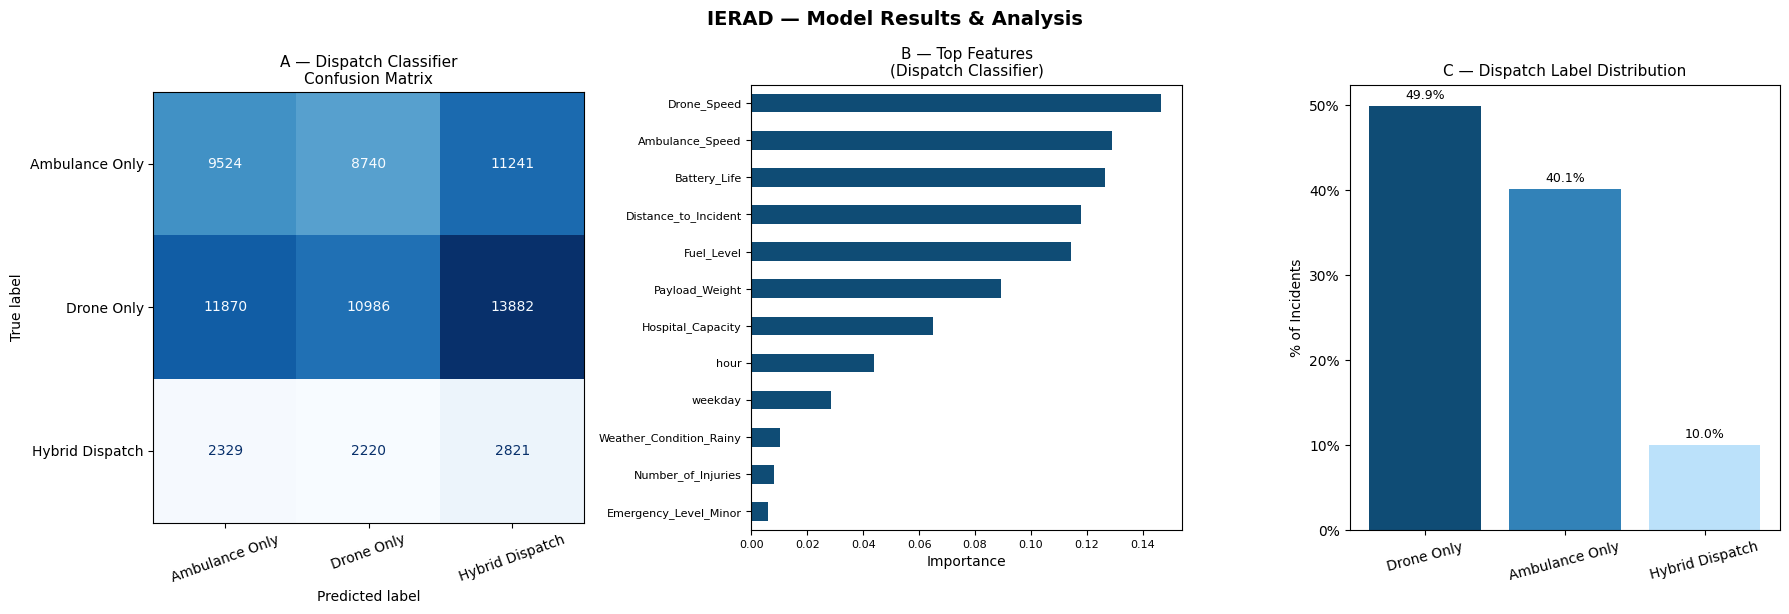

2026-03-30 21:59:24 | INFO     | Pipeline complete — see pipeline.log for full run details


In [13]:
try:
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle("IERAD — Model Results & Analysis", fontsize=14, fontweight="bold")
    plt.subplots_adjust(wspace=0.4)

    COLORS = ["#0F4C75", "#3282B8", "#BBE1FA"]

    # Panel A — Confusion Matrix
    # Rows = true label, columns = predicted label
    # Diagonal cells = correct predictions; off-diagonal = misclassifications
    ax = axes[0]
    cm = confusion_matrix(yc_test, yc_pred, labels=clf_pipeline.classes_)
    disp = ConfusionMatrixDisplay(cm, display_labels=clf_pipeline.classes_)
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title("A — Dispatch Classifier\nConfusion Matrix", fontsize=11)
    ax.tick_params(axis="x", labelrotation=20)

    # Panel B — Feature Importances
    # Sorted ascending so the most important feature appears at the top
    # Helps dispatchers understand which operational factors most influence recommendations
    ax = axes[1]
    clf_imp.sort_values().plot(kind="barh", ax=ax, color=COLORS[0])
    ax.set_title("B — Top Features\n(Dispatch Classifier)", fontsize=11)
    ax.set_xlabel("Importance")
    ax.tick_params(labelsize=8)

    # Panel C — Label Distribution
    # Shows the class imbalance that required sample weight correction in training
    # Percentage labels are annotated above each bar for readability
    ax = axes[2]
    bars = ax.bar(q_labels["Label"], q_labels["pct"], color=COLORS[:len(q_labels)])
    ax.set_title("C — Dispatch Label Distribution", fontsize=11)
    ax.set_ylabel("% of Incidents")
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.tick_params(axis="x", labelrotation=15)
    for bar, pct in zip(bars, q_labels["pct"]):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.5, f"{pct}%",
                ha="center", va="bottom", fontsize=9)

    plt.tight_layout()

    # Save before show() — show() clears the figure in some notebook environments
    output_path = "ierad_results.png"
    plt.savefig(output_path, dpi=150, bbox_inches="tight")
    logger.info(f"Figure saved to {output_path}")
    plt.show()

except Exception as e:
    logger.error(f"Visualization failed: {e}")
    raise
finally:
    # Always close figures to free memory, even if an error occurred mid-render
    plt.close("all")
    logger.info("Pipeline complete — see pipeline.log for full run details")